In [53]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install ast

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os
import subprocess

%matplotlib inline

In [55]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

# Color palette for classes
# {'Electro-mechanical', 'Geonature', 'Animal', 'Other human', 'Social/communal', 'Human movement', 'Music', 'Motorised transport', 'Voice', 'Other Sounds', 'Background'}
# LENGTH 11

# blue, red, green, orange, purple, brown, pink, black, yellow, grey,

COLLOR_PALLET = {
            'Other human': '#2986cc', # BLUE
            'Electro-mechanical': '#cc0000', # RED
            'Voice': '#6aa84f', #  green 6aa84f
            'Motorised transport': '#ffa500', # orange
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Music': '#d172a4', # PINK
            'Background': '#000000', # BLACK
            'Other Sounds': '#c9d631', # yellow
            'Social/communal': '#d8cbf8', # Light purple
            'Human movement': '#40b674', # light green 40b674
        }

In [56]:
# get the last git tag version
def list_git_tags():
    try:
        tags = tags = subprocess.check_output(["git", "tag"]).strip().decode()
        return tags.split('\n')
    except subprocess.CalledProcessError:
        return None
    
def select_tag(tags):
    for i, tag in enumerate(tags):
        print(f"{i}: {tag}")
    choice = int(input("Select the tag to use: "))
    tag_selected = tags[choice]
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
        
    return tag_selected

def get_stable_version():
    tags = list_git_tags()
    # get the latest stable version
    tag_selected = tags[-1]
    print(f"Latest stable version: {tag_selected}")
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
    
    print(f"Latest stable version: {tag_selected}")
    
    return tag_selected

stable_version = get_stable_version()

Latest stable version: v1.0
Latest stable version: v1_0


In [57]:
print(get_stable_version())

Latest stable version: v1.0
Latest stable version: v1_0
v1_0


In [58]:
def extract_location(file_path):
    file_name = os.path.basename(file_path)
    # print(f"File name: {file_name}")
    # Split the file name by the underscore
    file_name = file_name.split("_")[2]
    # print(f"File name after split: {file_name}")
    return file_name

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def change_label(classes_list, label, new_label):
    return [new_label if x == label else x for x in classes_list]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + "," + df["weekday"]

    return df

def output_dir(path: str):
    # get the abs path and remove the last element
    path = os.path.abspath(path).split("\\")[:-2]
    path = "/".join(path)
    
    visualization_dir = path + "/Visualizations"
    os.makedirs(visualization_dir, exist_ok=True)
    
    return visualization_dir

In [59]:
# example input path = \\192.168.205.117\AAC_Server\OCIO\Tests\TEST_AUDIOMOTH\BASURTO\Results\Urban_Model\Urban_Model_BASURTO_v1_0.csv

path_input = input("Enter the path to the csv file: ")

# make visualization directory
visualization_dir = output_dir(path_input)

# get the csv
df = pd.read_csv(path_input)

# get the location
title = extract_location(path_input)

df

FileNotFoundError: [Errno 2] No such file or directory: ''

In [ ]:
print("We are working with {} processing results".format(len(df)))
print(f"We are working within the time range from [ {df['datetime'].min()} ] to [ {df['datetime'].max()} ]")

df['datetime'] = pd.to_datetime(df['datetime'])
time_difference_seconds = df['datetime'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

We are working with 733 processing results
We are working within the time range from [ 2023-10-19 17:20:05 ] to [ 2023-10-27 12:18:25 ]
The average interval between each audio file is 15 minutes (920 seconds, which are 15 minutes)


In [ ]:
# convert string to list
df['classes_custom'] = df['classes_custom'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['classes_custom'])}")
print(f"Type of the first element: \t\t {type(df['classes_custom'][0])}")

# remove labels
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Nature'))
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Voice'))

# change labels
df['classes_custom'] = df['classes_custom'].apply(lambda x: change_label(x, 'Animal', 'Other Sounds'))

df['classes_custom']

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'list'>


0             [Voice, Other Sounds, Motorised transport]
1             [Voice, Other Sounds, Motorised transport]
2             [Voice, Other Sounds, Motorised transport]
3             [Motorised transport, Voice, Other Sounds]
4             [Motorised transport, Other Sounds, Voice]
                             ...                        
728    [Motorised transport, Other Sounds, Other Sounds]
729    [Other Sounds, Motorised transport, Other Sounds]
730           [Other Sounds, Motorised transport, Voice]
731           [Other Sounds, Motorised transport, Voice]
732      [Motorised transport, Other Sounds, Background]
Name: classes_custom, Length: 733, dtype: object

In [ ]:
# print("Nature" in df['classes_custom'])
# print("Voice" in df['classes_custom'])

In [ ]:
df['classes_custom'] = df['classes_custom'].apply(first_element)
df['classes_custom']

flatten_list = [item for sublist in df['classes_custom'] for item in sublist]
flatten_list

['Voice',
 'Voice',
 'Voice',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Motorised transport',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Voice',
 'Other human',
 'Other Sounds',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other Sounds',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other human',
 'Other Sounds',
 'Other human',
 'Other human',
 'Other Sounds',
 'Other Sounds',
 'Other Sounds',
 'Other Sounds',
 'Other Sounds',
 'Other Sounds',
 'Other Sounds',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised transport',
 'Motorised tran

In [ ]:
print(f"These are the class count:\n\n{df['classes_custom'].value_counts()}")

print(f"\nThese are the class summed: \t\t {df['classes_custom'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df)}")

These are the class count:

[Other Sounds]           232
[Voice]                  213
[Motorised transport]    182
[Geonature]               39
[Other human]             34
[Background]              30
[Music]                    3
Name: classes_custom, dtype: int64

These are the class summed: 		 733
This is the lenght of the dataframe 	 733


In [ ]:
df['single_class'] = df['classes_custom'].apply(lambda x: x[0] if x else None)
df.set_index("datetime", inplace=True)
df = insert_dates(df)

In [ ]:
df

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday
datetime,,,,,,,,,,,,,,,,
2023-10-19 17:20:05,20231019_172005.WAV,[Voice],[0.25823262 0.25823262 0.11069101],0.627156,"['Speech', 'Animal', 'Wild animals']","[0.293206, 0.05319693, 0.041956082]",0.388359,Voice,2023,10,19,17,20,5,Jueves,"19,Jueves"
2023-10-19 17:35:10,20231019_173510.WAV,[Voice],[0.24525717 0.24525717 0.11671371],0.607228,"['Speech', 'Animal', 'Wild animals']","[0.29281735, 0.05010562, 0.04270502]",0.385628,Voice,2023,10,19,17,35,10,Jueves,"19,Jueves"
2023-10-19 17:50:15,20231019_175015.WAV,[Voice],[0.17530662 0.17530662 0.17142264],0.522036,"['Speech', 'Vehicle', 'Inside, small room']","[0.22410046, 0.06600076, 0.038165625]",0.328267,Voice,2023,10,19,17,50,15,Jueves,"19,Jueves"
2023-10-19 18:05:20,20231019_180520.WAV,[Motorised transport],[0.20212826 0.20212826 0.14611305],0.550370,"['Speech', 'Vehicle', 'Inside, small room']","[0.19955753, 0.08403902, 0.043773096]",0.327370,Motorised transport,2023,10,19,18,5,20,Jueves,"19,Jueves"
2023-10-19 18:20:25,20231019_182025.WAV,[Motorised transport],[0.16463614 0.16463614 0.15379091],0.483063,"['Speech', 'Vehicle', 'Inside, small room']","[0.16615209, 0.10136902, 0.048920844]",0.316442,Motorised transport,2023,10,19,18,20,25,Jueves,"19,Jueves"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-27 11:18:05,20231027_111805.WAV,[Motorised transport],[0.18894473 0.18894473 0.14857468],0.526464,"['Vehicle', 'Inside, small room', 'Speech']","[0.13180082, 0.09504657, 0.05229931]",0.279147,Motorised transport,2023,10,27,11,18,5,Viernes,"27,Viernes"
2023-10-27 11:33:10,20231027_113310.WAV,[Other Sounds],[0.2009225 0.2009225 0.11750427],0.519349,"['Speech', 'Vehicle', 'Animal']","[0.10394454, 0.098571934, 0.06868903]",0.271206,Other Sounds,2023,10,27,11,33,10,Viernes,"27,Viernes"
2023-10-27 11:48:15,20231027_114815.WAV,[Other Sounds],[0.1679878 0.1679878 0.11770729],0.453683,"['Speech', 'Inside, small room', 'Vehicle']","[0.118583664, 0.07688012, 0.07128147]",0.266745,Other Sounds,2023,10,27,11,48,15,Viernes,"27,Viernes"


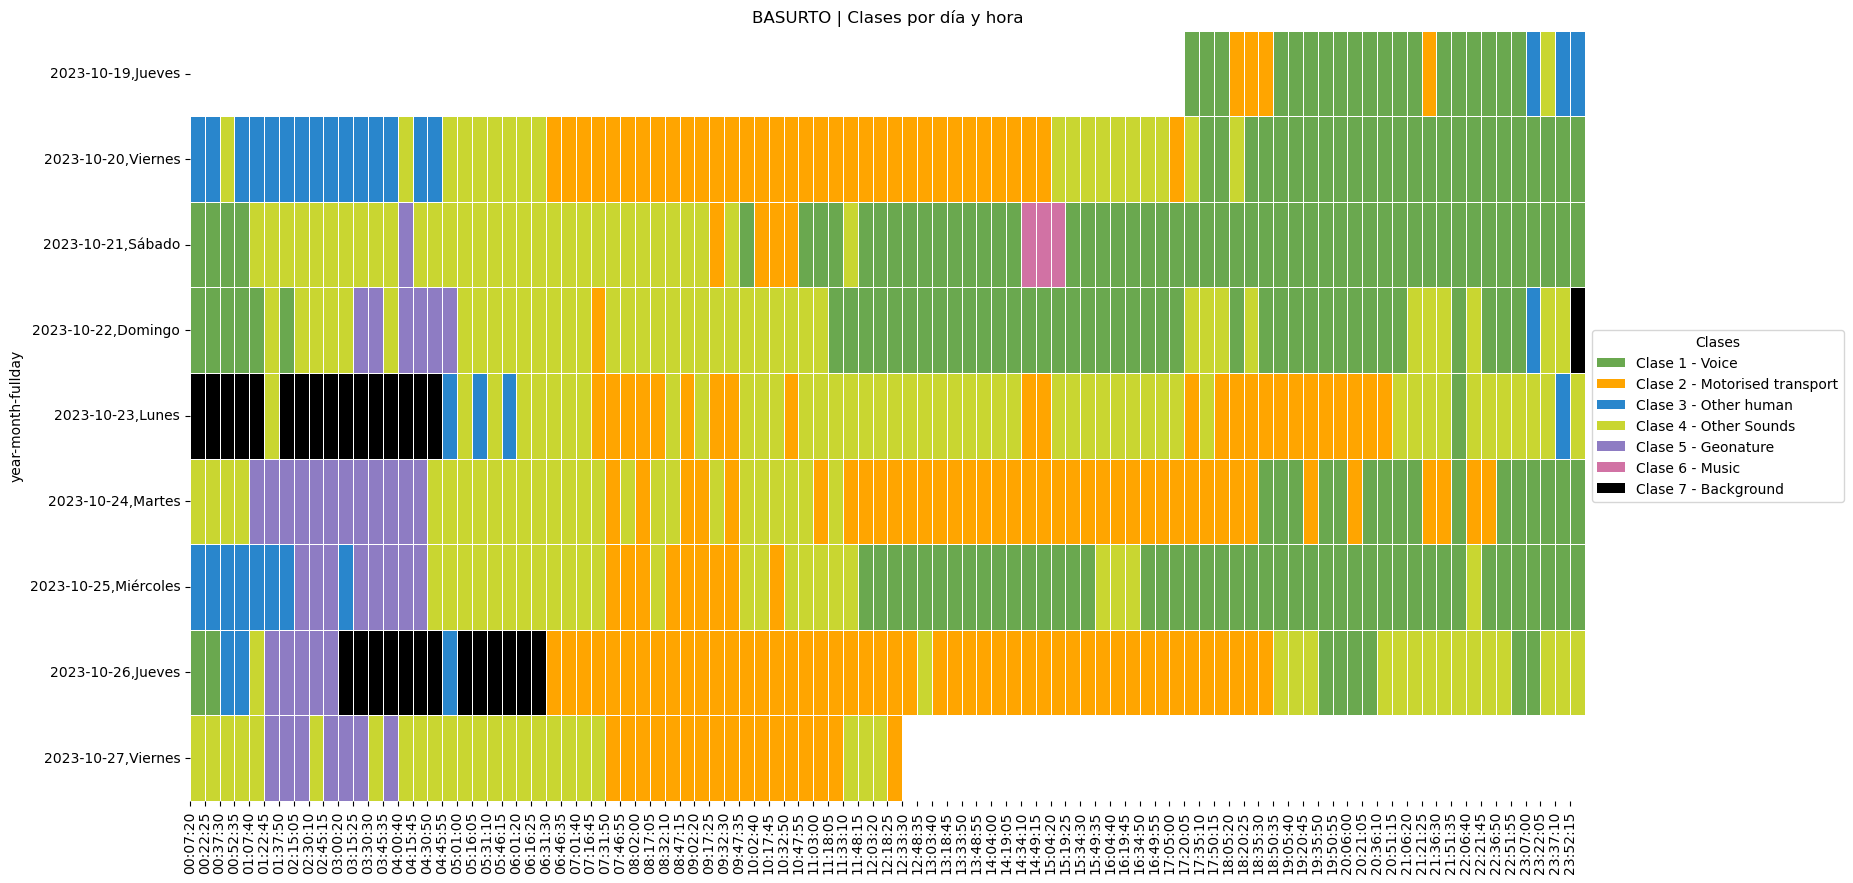

In [ ]:
df = df.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df['single_class'].unique())}
df['class_num'] = df['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df, columns=df.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(18, 10))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_color_map_{stable_version}.png", bbox_inches='tight')

plt.show()

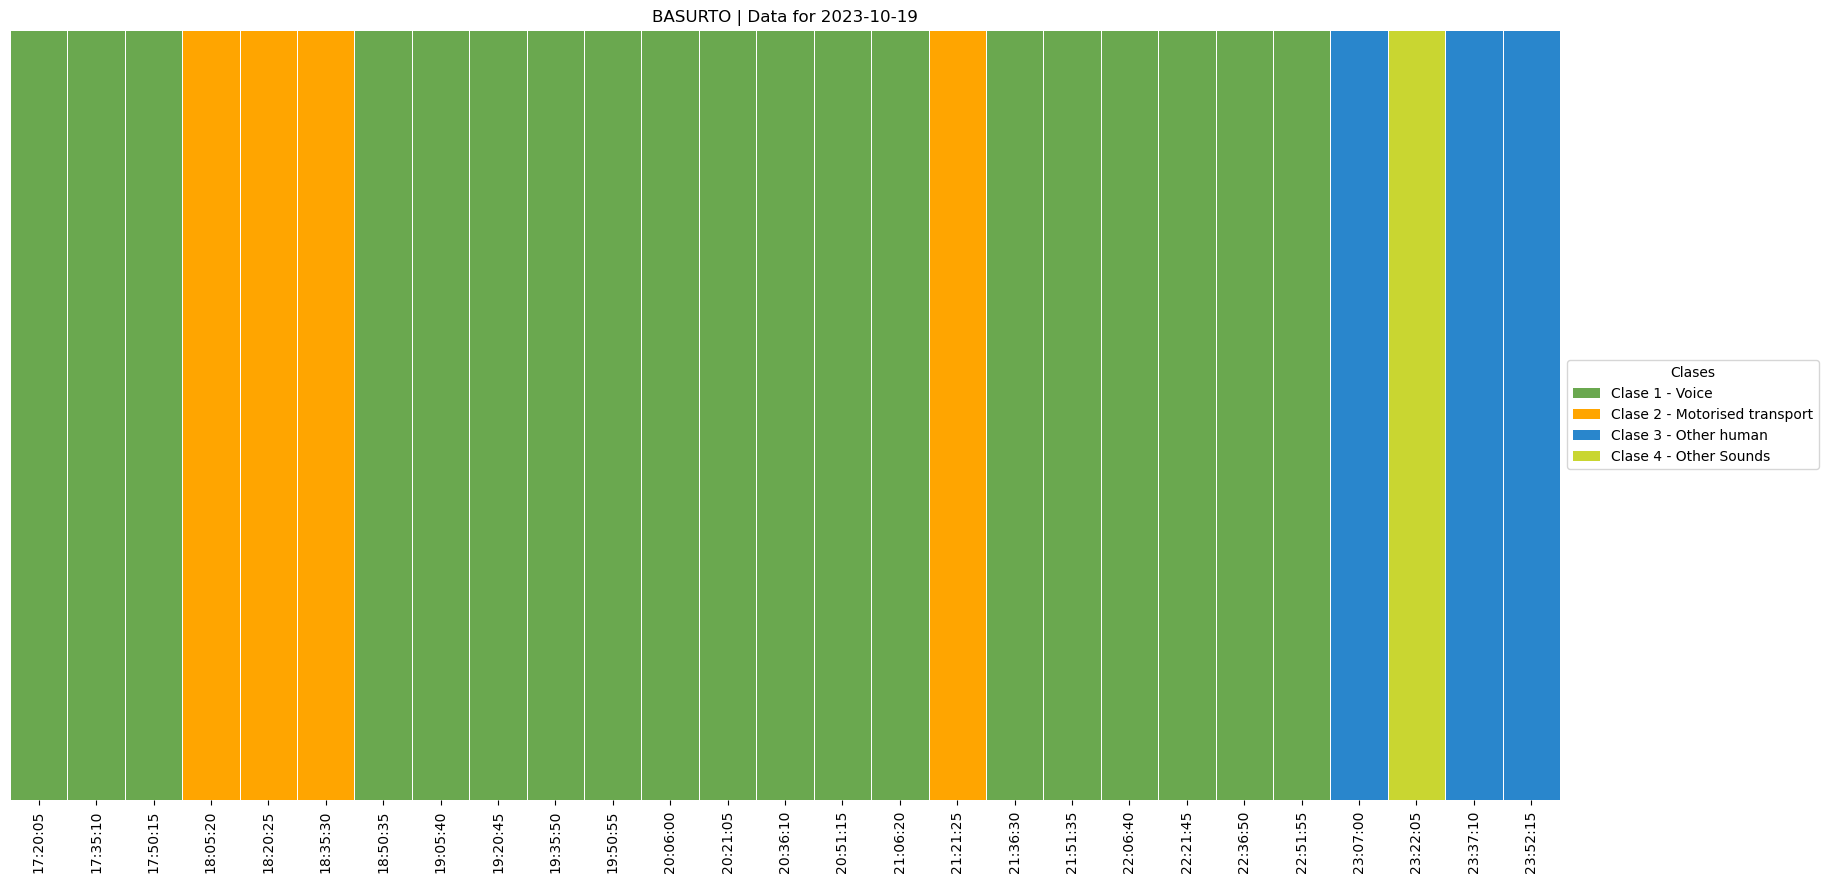

In [ ]:
day = "19"

# filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")

else:
    plt.figure(figsize=(20, 10))
    
    # pivot is used to get the heatmap | aggfunc is used to get the mode of the classes for each time
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")

    else:
        # unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # setup the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Hide the y-axis labels (to remove year and month labels)
        ax.yaxis.set_visible(False)
        
        # include the years and months in the dataset
        years = "-".join(map(str, sorted(df_xth["year"].unique())))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))

        # legend
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

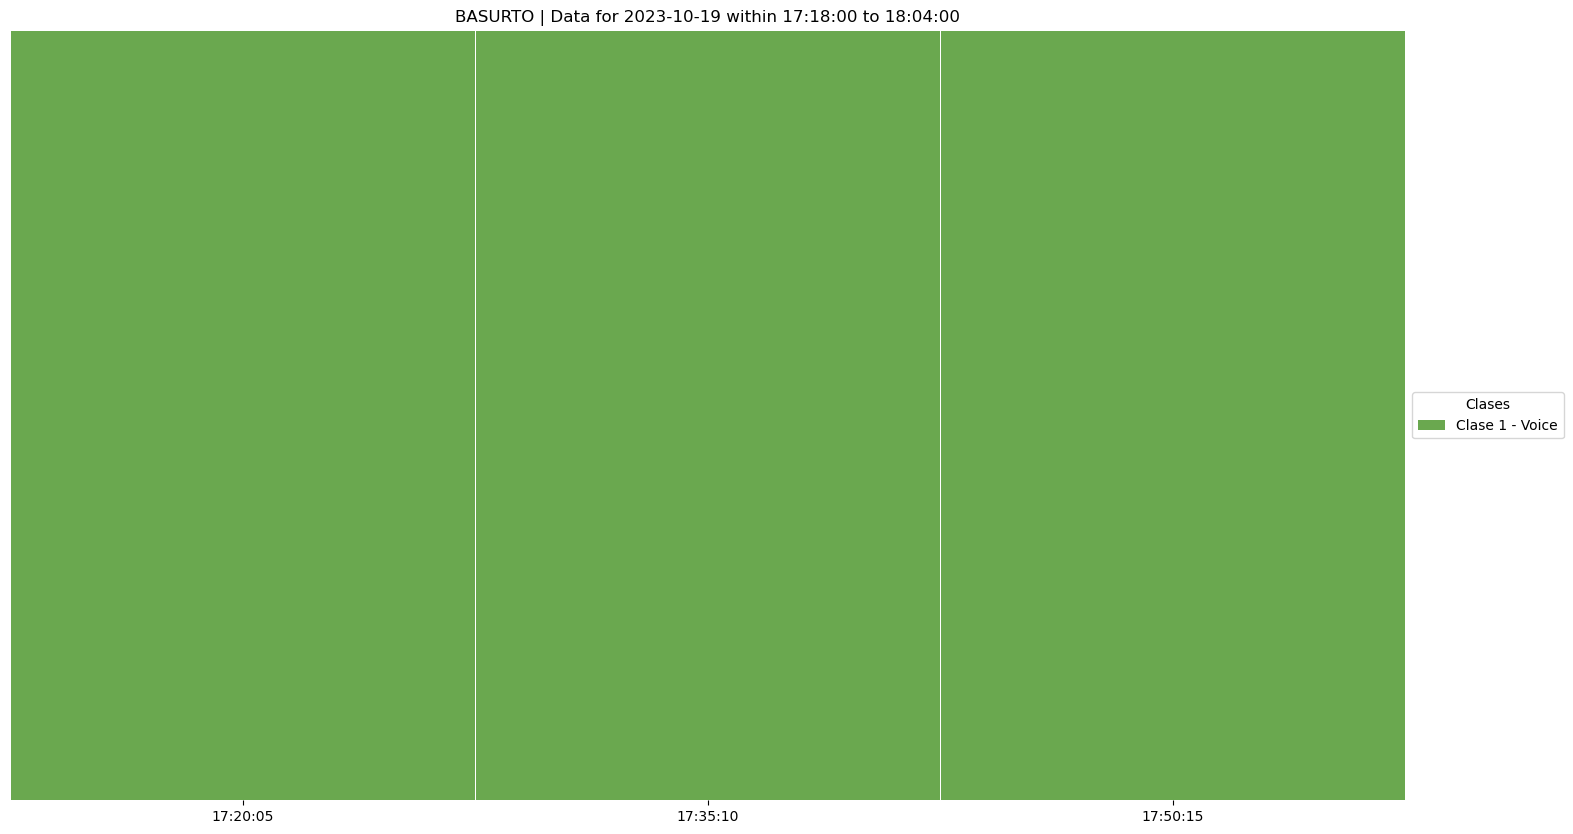

In [ ]:
day = "19"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("17:18:00").time()
        end_time = pd.to_datetime("18:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        # Get unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Create a list of colors in the order of class numbers
        cmap = [num_to_color[int(cls_num)] for cls_num in unique_classes if cls_num in name_class]

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=num_to_color[int(cls_num)], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # Create the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time.strftime('%H:%M:%S')} to {end_time.strftime('%H:%M:%S')}")

        plt.show()